<a href="https://colab.research.google.com/github/julia-zhmurko/JuliaZhmurko-ML/blob/main/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D1%96_%D1%80%D0%BE%D0%B1%D0%BE%D1%82%D0%B8/%D0%9B%D0%A04_%D0%9C%D0%9D_%D0%96%D0%BC%D1%83%D1%80%D0%BA%D0%BE_%D0%AE%D0%BB%D1%96%D1%8F_%D0%A4%D0%86%D0%A2_4_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота №4. Регресійні моделі: глибоке дослідження

**Датасет:** Car Price Prediction Multiple Linear Regression  
https://www.kaggle.com/datasets/hellbuoy/car-price-prediction?select=CarPrice_Assignment.csv

**Мета роботи:** виконати підготовку даних, побудувати та порівняти регресійні моделі для прогнозування ціни автомобіля, оцінити їх якість і проаналізувати отримані результати.

> У шаблоні наведено лише умови завдань. Реалізацію необхідно виконати самостійно у порожніх комірках.


**Автор:** студентка групи ФІТ 4-10 Жмурко Юлія Андріївна

**Була присутня на парі (23.09.2026)**

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib .pyplot as plt
import kagglehub
import os

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, PowerTransformer, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)

## 1. Завантаження та первинний аналіз даних

Завантажити датасет та виконати його первинний огляд:
- визначити кількість об'єктів і ознак;
- переглянути назви стовпців;
- визначити типи даних;
- визначити цільову змінну;
- вивести основні статистичні характеристики даних.


In [27]:
path = kagglehub.dataset_download("hellbuoy/car-price-prediction")
df = pd.read_csv(os.path.join(path, "CarPrice_Assignment.csv"))

print("Виведення рядків датасету:\n")
display(df)

Using Colab cache for faster access to the 'car-price-prediction' dataset.
Виведення рядків датасету:



,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0


**car_ID** - Унікальний ідентифікатор автомобіля

**symboling** - Категорія страхового ризику автомобіля

**CarName** - Марка та модель автомобіля

**fueltype** - Тип пального (gas, diesel)

**aspiration** - Тип подачі повітря до двигуна: стандартний або турбований

**doornumber** - Кількість дверей

**carbody** - Тип кузова автомобіля

**drivewheel** - Тип приводу: передній, задній або повний

**enginelocation** - Розташування двигуна

**wheelbase** - Колісна база автомобіля

**carlength** - Довжина автомобіля

**carwidth** - Ширина автомобіля

**carheight** - Висота автомобіля

**curbweight** - Споряджена маса автомобіля

**enginetype** - Тип двигуна

**cylindernumber** - Кількість циліндрів

**enginesize** - Робочий об'єм/розмір двигуна

**fuelsystem** - Тип паливної системи

**boreratio** - Діаметр циліндра / характеристика отвору циліндра

**stroke** - Хід поршня

**compressionratio** - Ступінь стиснення двигуна

**horsepower** - Потужність двигуна

**peakrpm** - Максимальна частота обертання двигуна

**citympg** - Паливна економічність під час руху містом

**highwaympg** - Паливна економічність на шосе

**price** - Ціна автомобіля — цільова змінна

In [28]:
#1 (визначити кількість об'єктів і ознак)
print("=== Розмірність датасету ===")
print(f"Кількість об'єктів (рядків): {df.shape[0]}")
print(f"Кількість ознак (стовпчиків): {df.shape[1]}\n")

=== Розмірність датасету ===
Кількість об'єктів (рядків): 205
Кількість ознак (стовпчиків): 26



In [29]:
#2 (переглянути назви стовпців)
print("=== Назви всіх стовпців ===")
print(df.columns.tolist(), "\n")

=== Назви всіх стовпців ===
['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price'] 



In [30]:
#3 (визначити типи даних)
print("=== Типи даних та інформація про пропуски ===\n")
df.info()

=== Типи даних та інформація про пропуски ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 1

In [31]:
#4 (визначити цільову змінну)
target_col = 'price'
print("=== Цільова змінна ===")
print(f"Цільова змінна: '{target_col}' (тип: {df[target_col].dtype})")

=== Цільова змінна ===
Цільова змінна: 'price' (тип: float64)


In [32]:
#5 (вивести основні статистичні характеристики даних)
print("=== Статистичні характеристики числових ознак ===")
display(df.describe())

print("\n=== Статистичні характеристики категоріальних ознак ===")
display(df.describe(include = ['object']))

=== Статистичні характеристики числових ознак ===


,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000



=== Статистичні характеристики категоріальних ознак ===


,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,enginetype,cylindernumber,fuelsystem
count,205,205,205,205,205,205,205,205,205,205
unique,147,2,2,2,5,3,2,7,7,8
top,peugeot 504,gas,std,four,sedan,fwd,front,ohc,four,mpfi
freq,6,185,168,115,96,120,202,148,159,94


# **Висновок до Завдання 1: Завантаження та первинний аналіз даних**

У результаті виконання первинного огляду датасету було завантажено 205 спостережень із 26 ознаками.

Структура даних охоплює 16 числових змінних та 10 категоріальних змінних типу `object`.

Усі стовпчики мають 205 заповнених записів, що свідчить про повну відсутність явних пропущених значень `NaN` на даному етапі.

Цільовою змінною для подальшого моделювання є ціна автомобіля (`price`), яка представлена числовим типом `float64`.

Згідно з описовою статистикою, вартість автомобілів коливається від 5.118 до 45.400.

При цьому середнє значення становить близько 13.276, що помітно перевищує медіанну ціну в 10.295.


## 2. Перевірка якості даних

Перевірити:
- наявність пропущених значень;
- наявність повних дублікатів;
- кількість унікальних значень в ознаках.

Під час аналізу врахувати, що `car_ID` є унікальним ідентифікатором автомобіля і сам по собі не повинен використовуватися для визначення дублікатів за змістовими характеристиками.


In [33]:
#1 (перевірити наявність пропущених значень
print("=== Перевірка пропущених значень ===")
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Пропущені значення': missing_values,
    'Відсоток (%)': missing_percent
})
display(missing_df[missing_df['Пропущені значення'] > 0])
if missing_values.sum() == 0:
    print("Пропущених значень (NaN) не виявлено\n")

=== Перевірка пропущених значень ===


,Пропущені значення,Відсоток (%)


Пропущених значень (NaN) не виявлено



In [34]:
#2 (перевірити наявність повних дублікатів)
print("=== Перевірка повних дублікатів ===")

full_duplicates = df.duplicated().sum()
print(f"Кількість повних дублікатів (включаючи car_ID): {full_duplicates}")

duplicates_no_id = df.drop(columns = ['car_ID']).duplicated().sum()
print(f"Кількість дублікатів за змістовими характеристиками (без car_ID): {duplicates_no_id}\n")

=== Перевірка повних дублікатів ===
Кількість повних дублікатів (включаючи car_ID): 0
Кількість дублікатів за змістовими характеристиками (без car_ID): 0



In [35]:
#3 (первірити кількість унікальних значень в ознаках)
print("=== Кількість унікальних значень в ознаках ===")
unique_counts = df.nunique()
unique_df = pd.DataFrame({
    'Тип даних': df.dtypes,
    'Кількість унікальних значень': unique_counts
})
display(unique_df)

=== Кількість унікальних значень в ознаках ===


,Тип даних,Кількість унікальних значень
car_ID,int64,205
symboling,int64,6
CarName,object,147
fueltype,object,2
aspiration,object,2
doornumber,object,2
carbody,object,5
drivewheel,object,3
enginelocation,object,2
wheelbase,float64,53


# **Висновок до Завдання 2: Перевірка якості даних**

Проведений аналіз якості даних показав повну відсутність явних пропущених значень (`NaN`) за всіма 26 ознаками датасету.

У результаті перевірки на наявність дублікатів не було виявлено жодного повторюваного запису - як з урахуванням ідентифікатора `car_ID`, так і за змістовими характеристиками автомобілів.

Аналіз унікальності значень підтвердив, що бінарні категоріальні ознаки (такі як `fueltype`, `aspiration`, `doornumber` та `enginelocation`) містять по 2 унікальних значення, тоді як числові параметри та назви моделей характеризуються високою різноманітністю.

## 3. Робота з car_ID

Зберегти `car_ID` окремо для подальшої ідентифікації автомобілів у результатах прогнозування.  
Не використовувати `car_ID` як ознаку під час навчання моделей.


In [36]:
car_ids = df['car_ID'].copy()

df_model = df.copy()
df_model["brand"] = (
    df_model["CarName"]
    .str.lower()
    .str.split()
    .str[0]
    .replace({
        "maxda": "mazda",
        "porcshce": "porsche",
        "toyouta": "toyota",
        "vokswagen": "volkswagen",
        "vw": "volkswagen",
    })
)

print("=== Кількість авто за марками (за допомогою groupby) ===")
brand_counts = df_model.groupby("brand").size().reset_index(name = "count").sort_values(by = "count", ascending = False)
display(brand_counts)

df_model = df_model.drop(columns = ["car_ID", "CarName"])

print(f"\nРозмірність датасету після обробки: {df_model.shape}")

=== Кількість авто за марками (за допомогою groupby) ===


,brand,count
19,toyota,32
12,nissan,18
9,mazda,17
11,mitsubishi,13
6,honda,13
18,subaru,12
20,volkswagen,12
13,peugeot,11
21,volvo,11
5,dodge,9



Розмірність датасету після обробки: (205, 25)


# **Висновок до Завдання 3: Робота з car_ID**

Унікальний ідентифікатор `car_ID` було відокремлено від основного датасету та збережено в окрему змінну `car_ids` для подальшого зіставлення прогнозів.

За допомогою групування `groupby` обраховано розподіл кількості авто за марками, де найбільшу частку становлять Toyota (32 авто), Nissan (18) та Mazda (17).

Початкові стовпчики `car_ID` та `CarName` вилучено з датасету для запобігання перенавчанню моделей.


## 4. Дослідження розподілів числових ознак

Дослідити розподіли числових ознак:
- побудувати відповідні графіки;
- обчислити коефіцієнти асиметрії;
- визначити ознаки з найбільш вираженою асиметрією;
- коротко прокоментувати отримані результати.


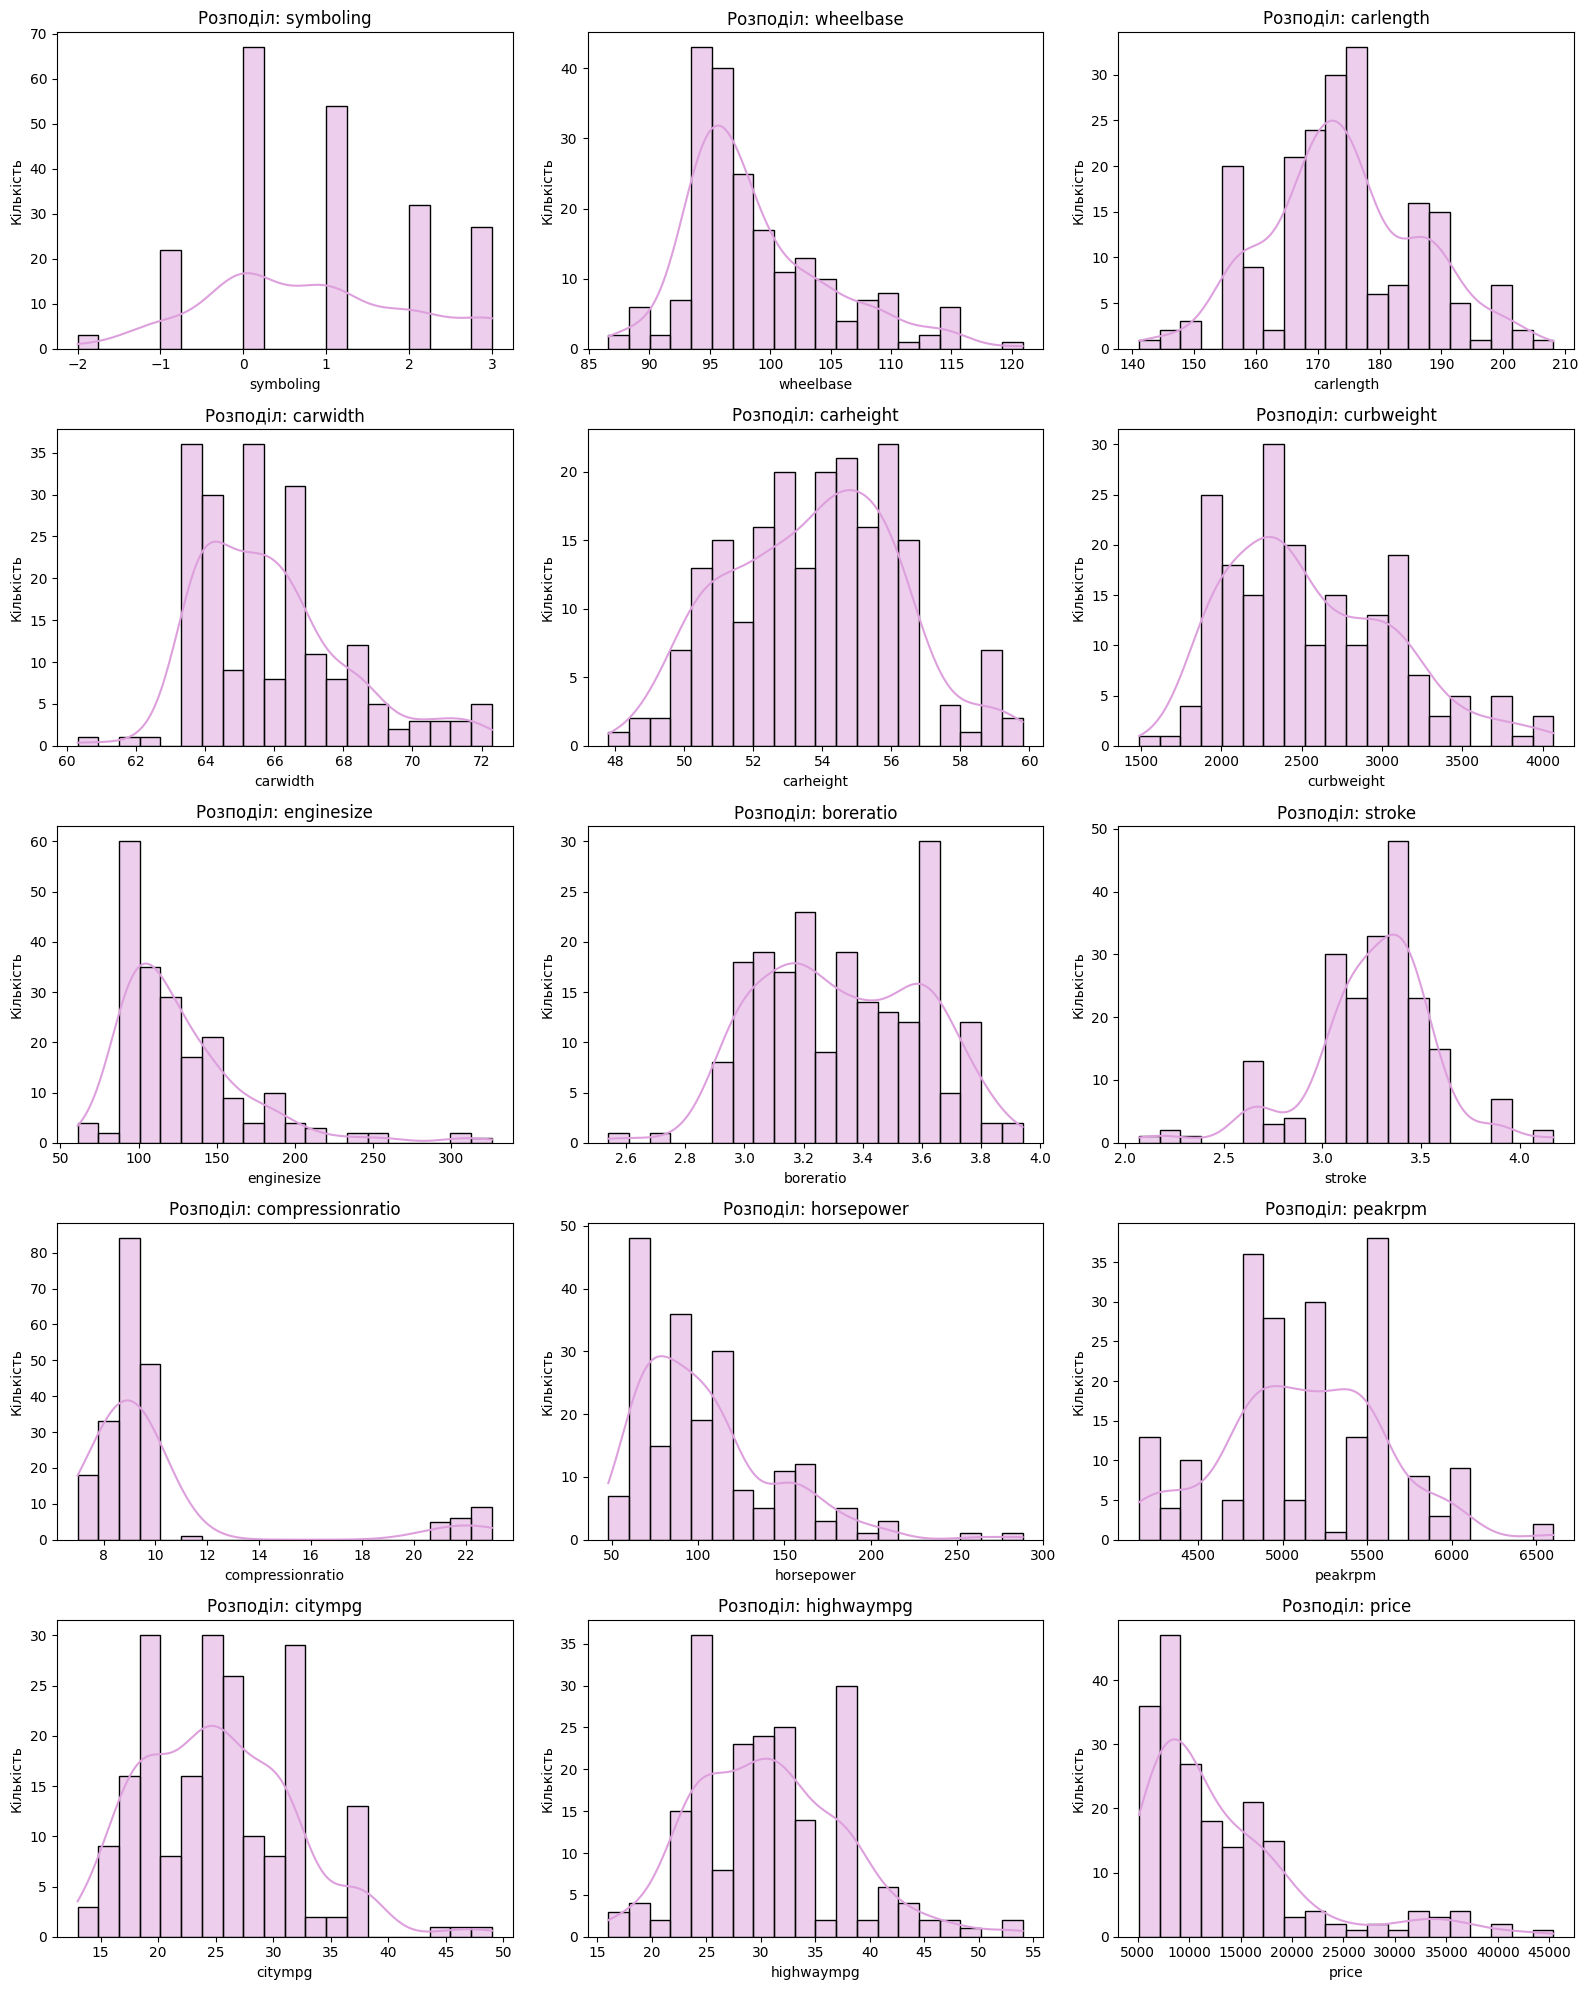

In [37]:
#1 (побудувати графіки розподілів числових ознак)
num_cols = df_model.select_dtypes(include = ["int64", "float64"]).columns

n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

plt.figure(figsize = (16, 4 * n_rows))
for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df_model[col], kde = True, color = "plum", bins = 20)
    plt.title(f"Розподіл: {col}")
    plt.xlabel(col)
    plt.ylabel("Кількість")

plt.tight_layout()
plt.show()

In [38]:
#2 (обчислити коефіцієнти асиметрії)
skewness = df_model[num_cols].skew().sort_values(ascending = False)

skew_df = pd.DataFrame(
    {
        "Ознака": skewness.index,
        "Коефіцієнт асиметрії (Skewness)": skewness.values,
    }
)

print("=== Коефіцієнти асиметрії для числових ознак ===")
display(skew_df)

=== Коефіцієнти асиметрії для числових ознак ===


,Ознака,Коефіцієнт асиметрії (Skewness)
0,compressionratio,2.610862
1,enginesize,1.947655
2,price,1.777678
3,horsepower,1.405310
4,wheelbase,1.050214
5,carwidth,0.904003
6,curbweight,0.681398
7,citympg,0.663704
8,highwaympg,0.539997
9,symboling,0.211072


In [39]:
#3 (визначити ознаки з найбільш вираженою асиметрією)
high_skew = skewness[abs(skewness) > 1]

print("=== Ознаки з найсильнішою асиметрією (|Skewness| > 1) ===")
display(high_skew.to_frame(name ="Skewness"))

=== Ознаки з найсильнішою асиметрією (|Skewness| > 1) ===


,Skewness
compressionratio,2.610862
enginesize,1.947655
price,1.777678
horsepower,1.405310
wheelbase,1.050214


# **Висновок до Завдання 4: Дослідження розподілів числових ознак**

   **Найбільш виражену правосторонню асиметрію ($Skewness > 1$)** мають 5 ознак: `compressionratio` (2.61), `enginesize` (1.95), `price` (1.78), `horsepower` (1.41) та `wheelbase` (1.05).

   **Помірну та симетричну форму ($\vert{}Skewness\vert{} < 1$)** мають більшість інших параметрів (`carwidth`, `curbweight`, `citympg`, `highwaympg`, `symboling`, `carlength`, `peakrpm`, `carheight`, `boreratio`), що свідчить про їхню близькість до нормального розподілу.


   **Негативну (лівосторонню) асиметрію** демонструє лише ознака `stroke` (-0.69).

## 5. Формування train/test вибірок

Відокремити цільову змінну `price` від ознак та розділити дані на:
- навчальну вибірку — 80%;
- тестову вибірку — 20%.

Забезпечити відтворюваність поділу.  
Окремо зберегти `car_ID` для об'єктів, які потрапили до train і test.

**Важливо:** усі подальші параметри передобробки даних визначати тільки за навчальною вибіркою.


In [40]:
# Відокремлюємо цільову змінну price від інших ознак (X)
X = df_model.drop(columns = ["price"])
y = df_model["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.20,
    random_state = 42,
)

# Окремо зберігаємо car_ID для об'єктів, які потрапили до train і test за їхніми індексами
car_id_train = car_ids.loc[X_train.index]
car_id_test = car_ids.loc[X_test.index]

print(f"Розмірність X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Розмірність X_test: {X_test.shape}, y_test: {y_test.shape}")
print(f"Збережено car_ID у train: {len(car_id_train)}, у test: {len(car_id_test)}")

Розмірність X_train: (164, 24), y_train: (164,)
Розмірність X_test: (41, 24), y_test: (41,)
Збережено car_ID у train: 164, у test: 41


# **Висновок до Завдання 5: Формування train/test вибірок**

Вибірку було розділено на навчальну (`X_train`: 164 об'єкти, 80%) та тестову (`X_test`: 41 об'єкт, 20%).

Для забезпечення відтворюваності експериментів зафіксовано значення `random_state = 42`.

Унікальні ідентифікатори `car_ID` вилучено зі складу матриць ознак і збережено в окремі вектори `car_id_train` (164 елементи) та `car_id_test` (41 елемент) шляхом індексації `.loc[X_train.index]` та `.loc[X_test.index]`.


## 6. Аналіз та обробка викидів

Для неперервних числових ознак навчальної вибірки:
- визначити потенційні викиди методом IQR;
- вивести кількість потенційних викидів для кожної ознаки;
- обґрунтувати спосіб їх обробки.

Для невеликого набору даних не видаляти автоматично всі рядки з викидами. Використати обмеження крайніх значень межами, визначеними за навчальною вибіркою.

Цільову змінну `price` не використовувати для визначення меж викидів.  
До тестової вибірки застосувати ті самі межі, які були отримані за train.


In [41]:
# Вибираємо всі числові ознаки з X_train (без цільової змінної price)
numeric_cols = X_train.select_dtypes(include = [np.number]).columns.tolist()

# Словник для збереження меж (Upper/Lower Bound), розрахованих виключно на train
bounds = {}
outlier_summary = []

# Визначення потенційних викидів методом IQR на навчальній вибірці
for col in numeric_cols:
    q1 = X_train[col].quantile(0.25)
    q3 = X_train[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    bounds[col] = (lower_bound, upper_bound)

    # Кількість викидів
    train_outliers = ((X_train[col] < lower_bound) | (X_train[col] > upper_bound)).sum()
    test_outliers = ((X_test[col] < lower_bound) | (X_test[col] > upper_bound)).sum()

    outlier_summary.append({
        'Ознака': col,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'Нижня межа': lower_bound,
        'Верхня межа': upper_bound,
        'Викиди (train)': train_outliers,
        'Викиди (test)': test_outliers
    })

df_outliers = pd.DataFrame(outlier_summary)
print("=== Таблиця аналізу викидів ДО обробки ===")
print(df_outliers[['Ознака', 'Нижня межа', 'Верхня межа', 'Викиди (train)', 'Викиди (test)']])

# Обробка викидів способом обмеження крайніх значень
# Створюємо копії вибірок для збереження оброблених даних
X_train_clean = X_train.copy()
X_test_clean = X_test.copy()

for col in numeric_cols:
    lower_bound, upper_bound = bounds[col]

    # Обмежуємо значення в train та test межами, отриманими за train
    X_train_clean[col] = X_train_clean[col].clip(
        lower = lower_bound,
        upper = upper_bound)

    X_test_clean[col] = X_test_clean[col].clip(
        lower = lower_bound,
        upper = upper_bound)

# Присвоюємо оброблені дані назад в X_train та X_test
X_train = X_train_clean
X_test = X_test_clean

print("\n Обробку викидів методом обмеження (clipping) успішно виконано для X_train та X_test")

=== Таблиця аналізу викидів ДО обробки ===
              Ознака  Нижня межа  Верхня межа  Викиди (train)  Викиди (test)
0          symboling     -3.0000       5.0000               0              0
1          wheelbase     83.1000     113.5000               6              1
2          carlength    141.8875     207.9875               0              2
3           carwidth     60.4250      70.4250              10              2
4          carheight     46.4625      60.9625               0              0
5         curbweight    998.6250    4103.6250               0              0
6         enginesize     33.5000     205.5000               7              3
7          boreratio      2.5650       4.1250               1              0
8             stroke      2.6600       3.8600              16              4
9   compressionratio      7.4000      10.6000              20              8
10        horsepower      4.7500     182.7500               7              1
11           peakrpm   3750.0000 

# **Висновок до Завдання 6: Аналіз та обробка викидів**

Для всіх неперервних числових ознак навчальної вибірки (`X_train`) обчислено міжквартильний розмах ($IQR = Q3 - Q1$) та межі потенційних викидів $[Q1 - 1.5 \cdot IQR, Q3 + 1.5 \cdot IQR]$.

Найбільшу кількість викидів зафіксовано в ознаках `compressionratio` (20), `stroke` (16), `carwidth` (10), `horsepower` (7) та `enginesize` (7).

Видалення спостережень з викидами призвело б до суттєвої втрати даних у малому датасеті (164 об'єкти в `train`), тому було застосовано метод **обмеження крайніх значень (clipping)**.

Усі межі обчислено виключно на навчальній вибірці `X_train`. Отримані фіксовані межі застосовано до `X_train` та `X_test` за допомогою методу `.clip()`. Цільова змінна `price` для визначення меж викидів не використовувалась.

## 7. Аналіз кореляцій та відбір ознак

За навчальною вибіркою:
- побудувати матрицю кореляцій числових ознак;
- знайти пари ознак із сильною кореляцією, для яких `|r| > 0.85`;
- для кожної такої пари залишити одну ознаку;
- під час вибору врахувати силу зв'язку кожної ознаки з цільовою змінною `price`;
- вивести список сильно корельованих пар та перелік ознак, які видаляються.

Із тестової вибірки видалити ті самі ознаки.  
Не використовувати тестову вибірку для прийняття рішення про відбір ознак.


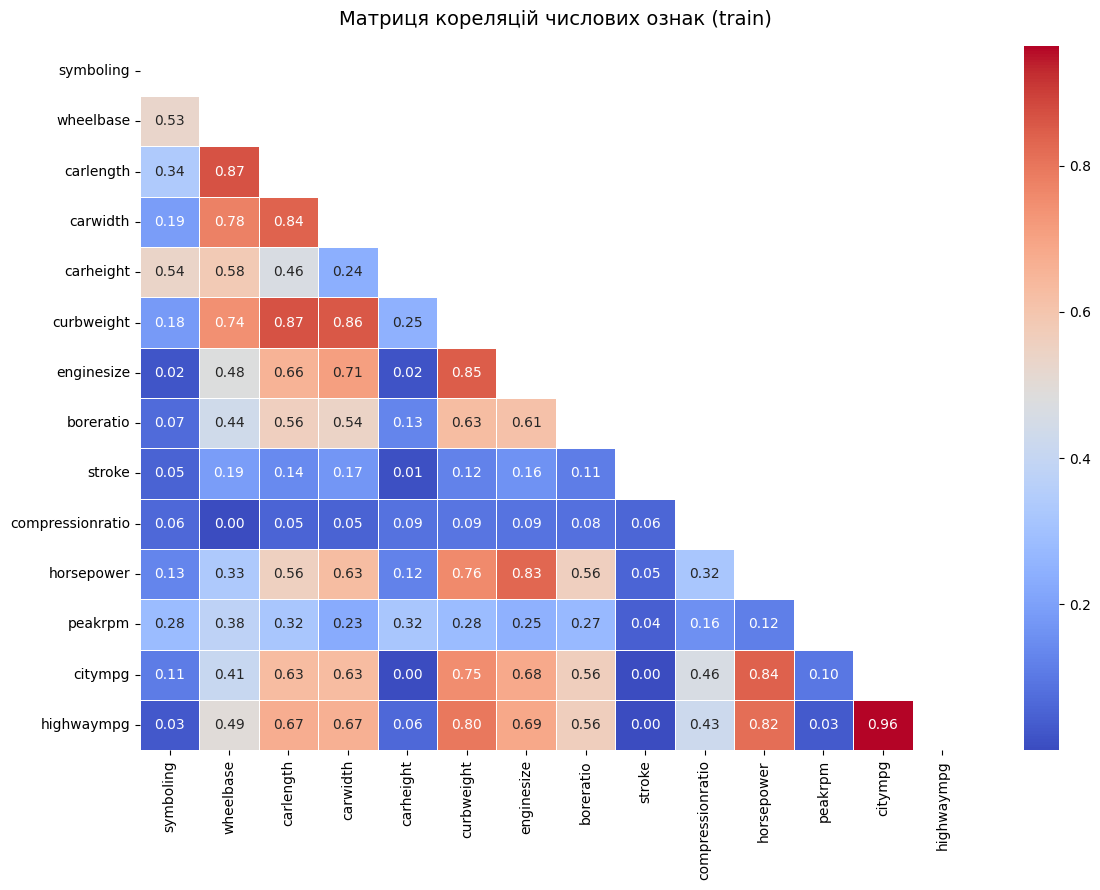

In [42]:
numeric_cols = X_train.select_dtypes(include = [np.number]).columns.tolist()

corr_matrix = X_train[numeric_cols].corr().abs()

mask = np.triu(np.ones_like(corr_matrix, dtype = bool), k = 0)

plt.figure(figsize = (12, 9))
sns.heatmap(
    corr_matrix,
    mask = mask,
    annot = True,
    fmt = ".2f",
    cmap = "coolwarm",
    linewidths = 0.5,
)
plt.title("Матриця кореляцій числових ознак (train)", fontsize = 14, pad = 15)
plt.tight_layout()
plt.show()

# Розраховуємо абсолютну кореляцію кожної ознаки з цільовою змінною price (y_train)
target_corr = X_train[numeric_cols].apply(lambda col: abs(col.corr(y_train)))

high_corr_pairs = []
cols_to_drop = set()

# Проходимо по трикутній матриці пар
for i in range(len(numeric_cols)):
    for j in range(i + 1, len(numeric_cols)):
        col1 = numeric_cols[i]
        col2 = numeric_cols[j]
        r = corr_matrix.loc[col1, col2]

        if abs(r) > 0.85:
            # Визначаємо силу зв'язку кожної ознаки з цільовою змінною price
            r_target1 = target_corr[col1]
            r_target2 = target_corr[col2]

            # Для кожної такої пари залишаємо ознаку з більшим зв'язком до price
            if r_target1 >= r_target2:
                keep_col, drop_col = col1, col2
            else:
                keep_col, drop_col = col2, col1

            cols_to_drop.add(drop_col)

            high_corr_pairs.append({
                'Ознака 1': col1,
                'Ознака 2': col2,
                '|r| (між собою)': abs(r),
                '|r(Ознака 1, price)|': r_target1,
                '|r(Ознака 2, price)|': r_target2,
                'Залишаємо': keep_col,
                'Видаляємо': drop_col
            })

In [43]:
df_high_corr = pd.DataFrame(high_corr_pairs)
print("=== Список сильно корельованих пар (|r| > 0.85) ===")
display(df_high_corr)

cols_to_drop_list = sorted(list(cols_to_drop))
print("\n=== Перелік ознак, які підлягають видаленню ===")
print(cols_to_drop_list)

X_train = X_train.drop(columns = cols_to_drop_list)
X_test = X_test.drop(columns = cols_to_drop_list)

print(f"\n Ознаки {cols_to_drop_list} успішно видалено з X_train та X_test")
print(f"Розмірність X_train після видалення: {X_train.shape}")
print(f"Розмірність X_test після видалення: {X_test.shape}")

=== Список сильно корельованих пар (|r| > 0.85) ===


,Ознака 1,Ознака 2,|r| (між собою),"|r(Ознака 1, price)|","|r(Ознака 2, price)|",Залишаємо,Видаляємо
0,wheelbase,carlength,0.867043,0.504036,0.652071,carlength,wheelbase
1,carlength,curbweight,0.865988,0.652071,0.824212,curbweight,carlength
2,carwidth,curbweight,0.858047,0.731623,0.824212,curbweight,carwidth
3,citympg,highwaympg,0.963620,0.711245,0.716460,highwaympg,citympg



=== Перелік ознак, які підлягають видаленню ===
['carlength', 'carwidth', 'citympg', 'wheelbase']

 Ознаки ['carlength', 'carwidth', 'citympg', 'wheelbase'] успішно видалено з X_train та X_test
Розмірність X_train після видалення: (164, 20)
Розмірність X_test після видалення: (41, 20)


# **Висновок до Завдання 7: Аналіз кореляцій та відбір ознак**

 Було побудовано теплову карту кореляцій Пірсона для неперервних числових ознак навчальної вибірки `X_train` у вигляді нижнього трикутника.

У результаті аналізу виявлено 4 пари сильно корельованих ознак:
   * **`wheelbase` та `carlength`** ($\vert{}r\vert{} \approx 0.87$): `carlength` має сильніший зв'язок із `price` (0.65 проти 0.50), тому вилучено **`wheelbase`**.
   * **`carlength` та `curbweight`** ($\vert{}r\vert{} \approx 0.87$): `curbweight` має сильніший зв'язок із `price` (0.82 проти 0.65), тому вилучено **`carlength`**.
   * **`carwidth` та `curbweight`** ($\vert{}r\vert{} \approx 0.86$): `curbweight` має сильніший зв'язок із `price` (0.82 проти 0.73), тому вилучено **`carwidth`**.
   * **`citympg` та `highwaympg`** ($\vert{}r\vert{} \approx 0.96$): `highwaympg` має сильніший зв'язок із `price` (0.72 проти 0.71), тому вилучено **`citympg`**.

З матриць ознак `X_train` та `X_test` було видалено 4 ознаки: `['carlength', 'carwidth', 'citympg', 'wheelbase']`. Кількість ознак у вибірках зменшилася з 24 до 20.

 Усі рішення щодо відбору та вилучення ознак приймалися виключно на основі навчальної вибірки `X_train`. Тестова вибірка `X_test` задіяна лише для видалення тих самих колонок.

## 8. Підготовка числових і категоріальних ознак

Розділити ознаки на:
- неперервні числові;
- дискретну числову ознаку `symboling`;
- категоріальні.

Для неперервних числових ознак виконати послідовно:
1. перетворення Yeo–Johnson для зменшення асиметрії;
2. масштабування за допомогою StandardScaler.

Для `symboling` виконати масштабування без Yeo–Johnson.

Категоріальні ознаки закодувати методом One-Hot Encoding. Передбачити коректну обробку категорій у test, яких не було у train.

Усі перетворення об'єднати в єдиний механізм передобробки даних, який навчається тільки на `X_train`.


In [44]:
discrete_cols = ['symboling']

categorical_cols = X_train.select_dtypes(include = ['object', 'category']).columns.tolist()

num_cols = X_train.select_dtypes(include = [np.number]).columns.tolist()
continuous_cols = [col for col in num_cols if col not in discrete_cols]

print("Неперервні числові ознаки:", continuous_cols)
print("\nДискретна ознака:", discrete_cols)
print("\nКатегоріальні ознаки:", categorical_cols)

Неперервні числові ознаки: ['carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'highwaympg']

Дискретна ознака: ['symboling']

Категоріальні ознаки: ['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem', 'brand']


In [45]:
continuous_pipeline = Pipeline([
    ('yeo_johnson', PowerTransformer(method = 'yeo-johnson')),
    ('scaler', StandardScaler())
])

discrete_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('ohe', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False))
])

# Єдиний механізм передобробки даних (ColumnTransformer)
preprocessor = ColumnTransformer(
    transformers = [
        ('num_continuous', continuous_pipeline, continuous_cols),
        ('num_discrete', discrete_pipeline, discrete_cols),
        ('cat', categorical_pipeline, categorical_cols)
    ],
    verbose_feature_names_out = False
)

X_train_prep_array = preprocessor.fit_transform(X_train)

X_test_prep_array = preprocessor.transform(X_test)

# Отримуємо назви всіх закодованих ознак
feature_names = preprocessor.get_feature_names_out()

X_train_prep = pd.DataFrame(X_train_prep_array, columns = feature_names, index = X_train.index)
X_test_prep = pd.DataFrame(X_test_prep_array, columns = feature_names, index = X_test.index)

print(f"Розмірність підготовленого X_train: {X_train_prep.shape}")
print(f"Розмірність підготовленого X_test: {X_test_prep.shape}")

X_train_prep.head()

Розмірність підготовленого X_train: (164, 69)
Розмірність підготовленого X_test: (41, 69)


,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,highwaympg,symboling,...,brand_nissan,brand_peugeot,brand_plymouth,brand_porsche,brand_renault,brand_saab,brand_subaru,brand_toyota,brand_volkswagen,brand_volvo
66,0.283461,0.455778,0.540306,0.419807,1.470292,1.998322,-0.962378,-1.944939,1.291931,-0.727380,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
111,1.203945,1.063079,0.101671,0.529800,-2.022836,-0.845060,0.010873,-0.285652,-1.034713,-0.727380,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
153,2.151912,-0.439830,-1.147848,-1.009773,-0.884725,-0.057773,-1.559900,-0.696264,1.011557,-0.727380,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
96,0.323736,-1.320157,-0.875082,-0.626791,0.042883,0.461933,-1.126949,0.122373,1.011557,0.078636,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38,-0.161118,-0.417480,-0.275707,-0.626791,1.210481,-0.057773,-0.319702,1.332027,0.426961,-0.727380,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [46]:
skew_before = X_train[continuous_cols].skew()
skew_after = X_train_prep[continuous_cols].skew()

skewness_df = pd.DataFrame({
    'Skewness Before': skew_before,
    'Skewness After': skew_after
})

print("Порівняння асиметрії неперервних ознак до та після Yeo-Johnson:")
display(skewness_df)

Порівняння асиметрії неперервних ознак до та після Yeo-Johnson:


,Skewness Before,Skewness After
carheight,0.028154,-0.005170
curbweight,0.712433,0.049894
enginesize,0.962394,0.044834
boreratio,0.062963,-0.005941
stroke,-0.397600,0.015846
compressionratio,0.055710,0.004872
horsepower,0.850735,0.066280
peakrpm,0.039773,-0.003589
highwaympg,0.243761,-0.012188


# **Висновок до Завдання 8: Підготовка числових і категоріальних ознак**

Усі ознаки успішно розділено на три типи: неперервні числові (`continuous_cols`), дискретну числову (`symboling`) та категоріальні (`categorical_cols`).

Для неперервних ознак застосовано перетворення `Yeo-Johnson` (`PowerTransformer`) для зменшення асиметрії розподілів, після чого виконано масштабування за допомогою `StandardScaler`.

Для дискретної ознаки `symboling` виконано стандартизацію (`StandardScaler`) без попереднього перетворення `Yeo-Johnson`.

Категоріальні ознаки закодовано методом `One-Hot Encoding` з параметром `handle_unknown='ignore'`, що гарантує коректну обробку нових категорій у тестовому наборі (без виникнення помилок та із заповненням нулями).

Усі трансформації об'єднано в єдиний конвеєр передобробки (`ColumnTransformer`).

Конвеєр навчався виключно на тренувальній вибірці (`X_train`), після чого застосовувався до `X_train` та `X_test` за допомогою методів `.fit_transform()` та `.transform()` відповідно.

У результаті передобробки отримано датафрейми `X_train_prep` розмірністю (164, 69) та `X_test_prep` розмірністю (41, 69), повністю готові для подальшого навчання моделей машинного навчання.

Аналіз коефіцієнтів асиметрії до та після перетворення (`Skewness Before` vs `Skewness After`) підтвердив високу ефективність конвеєра: для всіх неперервних ознак значення скошеності суттєво зменшилися та наблизилися майже до 0.

## 9. Перевірка трансформації числових ознак

Перевірити результат трансформації неперервних числових ознак:
- застосувати до train ту саму послідовність перетворень, яка буде використана в моделях;
- повторно обчислити коефіцієнти асиметрії;
- порівняти їх із початковими значеннями;
- зробити короткий висновок щодо ефективності трансформації.


In [47]:
# Застосовуємо трансформацію Yeo-Johnson до навчальної вибірки
pt = PowerTransformer(method = 'yeo-johnson')
X_train_yeo = pd.DataFrame(
    pt.fit_transform(X_train[continuous_cols]),
    columns = continuous_cols,
    index = X_train.index
)

# Обчислюємо коефіцієнти асиметрії до та після перетворення
skew_before = X_train[continuous_cols].skew()
skew_after = X_train_yeo[continuous_cols].skew()

skew_comparison = pd.DataFrame({
    'Skewness Before': skew_before,
    'Skewness After': skew_after,
    'Difference': skew_after - skew_before
})

print("Порівняння коефіцієнтів асиметрії неперервних ознак (X_train):")
display(skew_comparison)

Порівняння коефіцієнтів асиметрії неперервних ознак (X_train):


,Skewness Before,Skewness After,Difference
carheight,0.028154,-0.005170,-0.033324
curbweight,0.712433,0.049894,-0.662539
enginesize,0.962394,0.044834,-0.917560
boreratio,0.062963,-0.005941,-0.068904
stroke,-0.397600,0.015846,0.413446
compressionratio,0.055710,0.004872,-0.050838
horsepower,0.850735,0.066280,-0.784455
peakrpm,0.039773,-0.003589,-0.043362
highwaympg,0.243761,-0.012188,-0.255949


# **Висновок до Завдання 9: Перевірка трансформації числових ознак**

До неперервних числових ознак навчальної вибірки (`X_train`) було застосовано перетворення Yeo-Johnson (`PowerTransformer`).

   * **`enginesize`**: асиметрія зменшилася з **`0.962`** до **`0.045`**.

   * **`horsepower`**: зменшилася з **`0.851`** до **`0.066`**.
   * **`curbweight`**: зменшилася з **`0.712`** до **`0.050`**.
   * **`highwaympg`**: зменшилася з **`0.244`** до **`-0.012`**.
   * Для ознак з початково низькою асиметрією (`carheight`, `boreratio`, `compressionratio`, `peakrpm`, `stroke`) значення також стабілізувалися в межах від **`-0.006`** до **`0.016`**.

   Перетворення **Yeo-Johnson продемонструвало високу ефективність**: усі неперервні ознаки успішно приведено до розподілу, близького до нормального (значення асиметрії наближені до `0`).

## 10. Побудова регресійних моделей

Побудувати та навчити такі моделі:
- Linear Regression;
- Ridge Regression;
- Lasso Regression;
- Random Forest Regressor;
- Gradient Boosting Regressor;
- Support Vector Regressor (SVR).

Для кожної моделі створити єдиний Pipeline, який містить:
1. попередню обробку ознак;
2. відповідну регресійну модель.

Використати однакову схему підготовки даних для коректного порівняння моделей.


In [48]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(random_state = 42),
    "Lasso Regression": Lasso(random_state = 42),
    "Random Forest Regressor": RandomForestRegressor(random_state = 42),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state = 42),
    "Support Vector Regressor (SVR)": SVR()
}

pipelines = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    pipelines[name] = pipe
    print(f" Модель '{name}' успішно підключена до Pipeline та навчена!")

 Модель 'Linear Regression' успішно підключена до Pipeline та навчена!
 Модель 'Ridge Regression' успішно підключена до Pipeline та навчена!
 Модель 'Lasso Regression' успішно підключена до Pipeline та навчена!
 Модель 'Random Forest Regressor' успішно підключена до Pipeline та навчена!
 Модель 'Gradient Boosting Regressor' успішно підключена до Pipeline та навчена!
 Модель 'Support Vector Regressor (SVR)' успішно підключена до Pipeline та навчена!


# **Висновок до Завдання 10: Побудова регресійних моделей**

Для забезпечення об'єктивного та коректного порівняння моделей використано єдиний механізм попередньої обробки даних `preprocessor` (`ColumnTransformer`), створений на етапі 8.

Для кожної з 6 моделей (`Linear Regression`, `Ridge`, `Lasso`, `Random Forest`, `Gradient Boosting`, `SVR`) побудовано `Pipeline`, що гарантує, що трансформації (Yeo-Johnson, масштабування `StandardScaler` та One-Hot кодування) застосовуються послідовно та без витоку даних.

Усі пайплайни успішно навчені на навчальній вибірці (`X_train`, `y_train`) та  підготовлені для подальшої оцінки точності прогнозування та порівняння метрик.

## 11. Оцінювання якості моделей

Для кожної моделі:
- виконати навчання на тренувальній вибірці;
- отримати прогноз для тестової вибірки;
- обчислити метрики **R², MAE, MSE та MAPE**.

`MAPE` подати у відсотках.

Результати всіх моделей об'єднати в одну порівняльну таблицю та впорядкувати за значенням R² від найбільшого до найменшого.

Під час інтерпретації врахувати:
- R² — чим більше, тим краще;
- MAE, MSE, MAPE — чим менше, тим краще.


In [49]:
results = []

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    #1 (виконати навчання на тренувальній вибірці)
    pipe.fit(X_train, y_train)

    #2 (отримати прогноз для тестової вибірки)
    y_pred = pipe.predict(X_test)

    #3 (обчислити метрики R², MAE, MSE та MAPE (у відсотках))
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    results.append({
        'Model': name,
        'R²': r2,
        'MAE': mae,
        'MSE': mse,
        'MAPE (%)': mape
    })

#4 (об'єднати в одну порівняльну таблицю та впорядкувати за R² від найбільшого до найменшого)
metrics_df = pd.DataFrame(results).sort_values(by = 'R²', ascending = False).reset_index(drop = True)

print("Порівняльна таблиця якості моделей на тестовій вибірці:")
display(metrics_df)

Порівняльна таблиця якості моделей на тестовій вибірці:


,Model,R²,MAE,MSE,MAPE (%)
0,Random Forest Regressor,0.954225,1351.187085,3.613633e+06,9.856585
1,Gradient Boosting Regressor,0.930420,1727.403684,5.492942e+06,12.050186
2,Linear Regression,0.879431,2156.098245,9.518236e+06,16.376447
3,Lasso Regression,0.878234,2105.214295,9.612671e+06,15.133568
4,Ridge Regression,0.853789,2367.223583,1.154249e+07,18.193087
5,Support Vector Regressor (SVR),-0.099732,5696.776966,8.681724e+07,36.027666


# **Висновок до Завдання 11: Оцінювання якості моделей**


   Модель **Random Forest Regressor** показала найвищу точність серед усіх протестованих алгоритмів. Вона досягла коефіцієнта детермінації **$\text{R}^2 \approx 0.954$**.

   Середня абсолютна помилка склала **$\text{MAE} \approx 1351.19$** доларів США, а відносна помилка прогнозування **$\text{MAPE} \approx 9.86\%$**, що є чудовим показником, оскільки середня помилка моделі не перевищує 10%.

   Модель **Gradient Boosting Regressor** також продемонструвала дуже високу точність із **$\text{R}^2 \approx 0.930$** та відносною помилкою **$\text{MAPE} \approx 12.05\%$**.

   Моделі **Linear Regression**, **Lasso** та **Ridge** показали досить близькі результати ($\text{R}^2$ у межах **$0.854 - 0.879$**).

   **Support Vector Regressor (SVR)** показав від'ємний коефіцієнт детермінації (**$\text{R}^2 \approx -0.099$**) та високу відносну помилку (**$\text{MAPE} \approx 36.03\%$**), що свідчить про те, що стандартні налаштування гіперпараметрів SVR без їх підбору є неефективними для даної задачі та дають прогноз гірший за константний.

Ансамблеві алгоритми на основі дерев рішень (особливо **Random Forest**) є найбільш оптимальним вибором для прогнозування вартості автомобілів у цьому датасеті.

## 12. Пояснення вибору типу моделі

Пояснити, чому класифікаційна модель, наприклад Logistic Regression, не підходить для безпосереднього прогнозування неперервної ціни автомобіля.

Зазначити, до якого типу задачі належить прогнозування `price` та чому моделі, використані в роботі, відповідають цій задачі.


# **Висновок до Завдання 12: Пояснення вибору типу моделі**

Класифікаційні моделі призначені для розділення об'єктів за дискретними категоріями або визначення ймовірності належності до конкретного класу (наприклад, «дешеве / дороге авто»).

Ціна автомобіля є неперервною числовою величиною, яка приймає будь-яке дійсне значення. Логістична регресія оптимізує функцію втрат *Log Loss* для передбачення класів і не здатна оцінювати кількісну величину помилки в грошовому еквіваленті.

Прогнозування вартості автомобіля належить до задачі **регресії (Regression)** у рамках машинного навчання з учителем (*Supervised Learning*), оскільки цільова змінна `price` є неперервною.

Моделі регресії відповідають цій задачі, оскільки вони розроблені для знаходження неперервної залежності та вимірювання помилки у грошовому еквіваленті.

Практичні результати роботи це підтверджують: ансамблева модель Random Forest Regressor виявилася найточнішою, досягнувши коефіцієнта детермінації $R^2 = 0.954$ та відносної помилки $MAPE = 9.86\%$ ($MAE \approx 1351.19\$$).

Водночас лінійні моделі (Linear, Lasso, Ridge) продемонстрували стійку точність на рівні $R^2 \approx 0.854 - 0.879$, підтверджуючи можливість оцінювати прямий грошовий внесок технічних характеристик авто у його підсумкову вартість.


## 13. Візуальне порівняння прогнозів

Для кожної побудованої моделі зобразити співвідношення:
- фактичних значень `price`;
- прогнозованих значень `price`.

Додати лінію ідеального прогнозу та проаналізувати, наскільки близько до неї розташовані прогнозовані значення. Звернути увагу на великі відхилення.


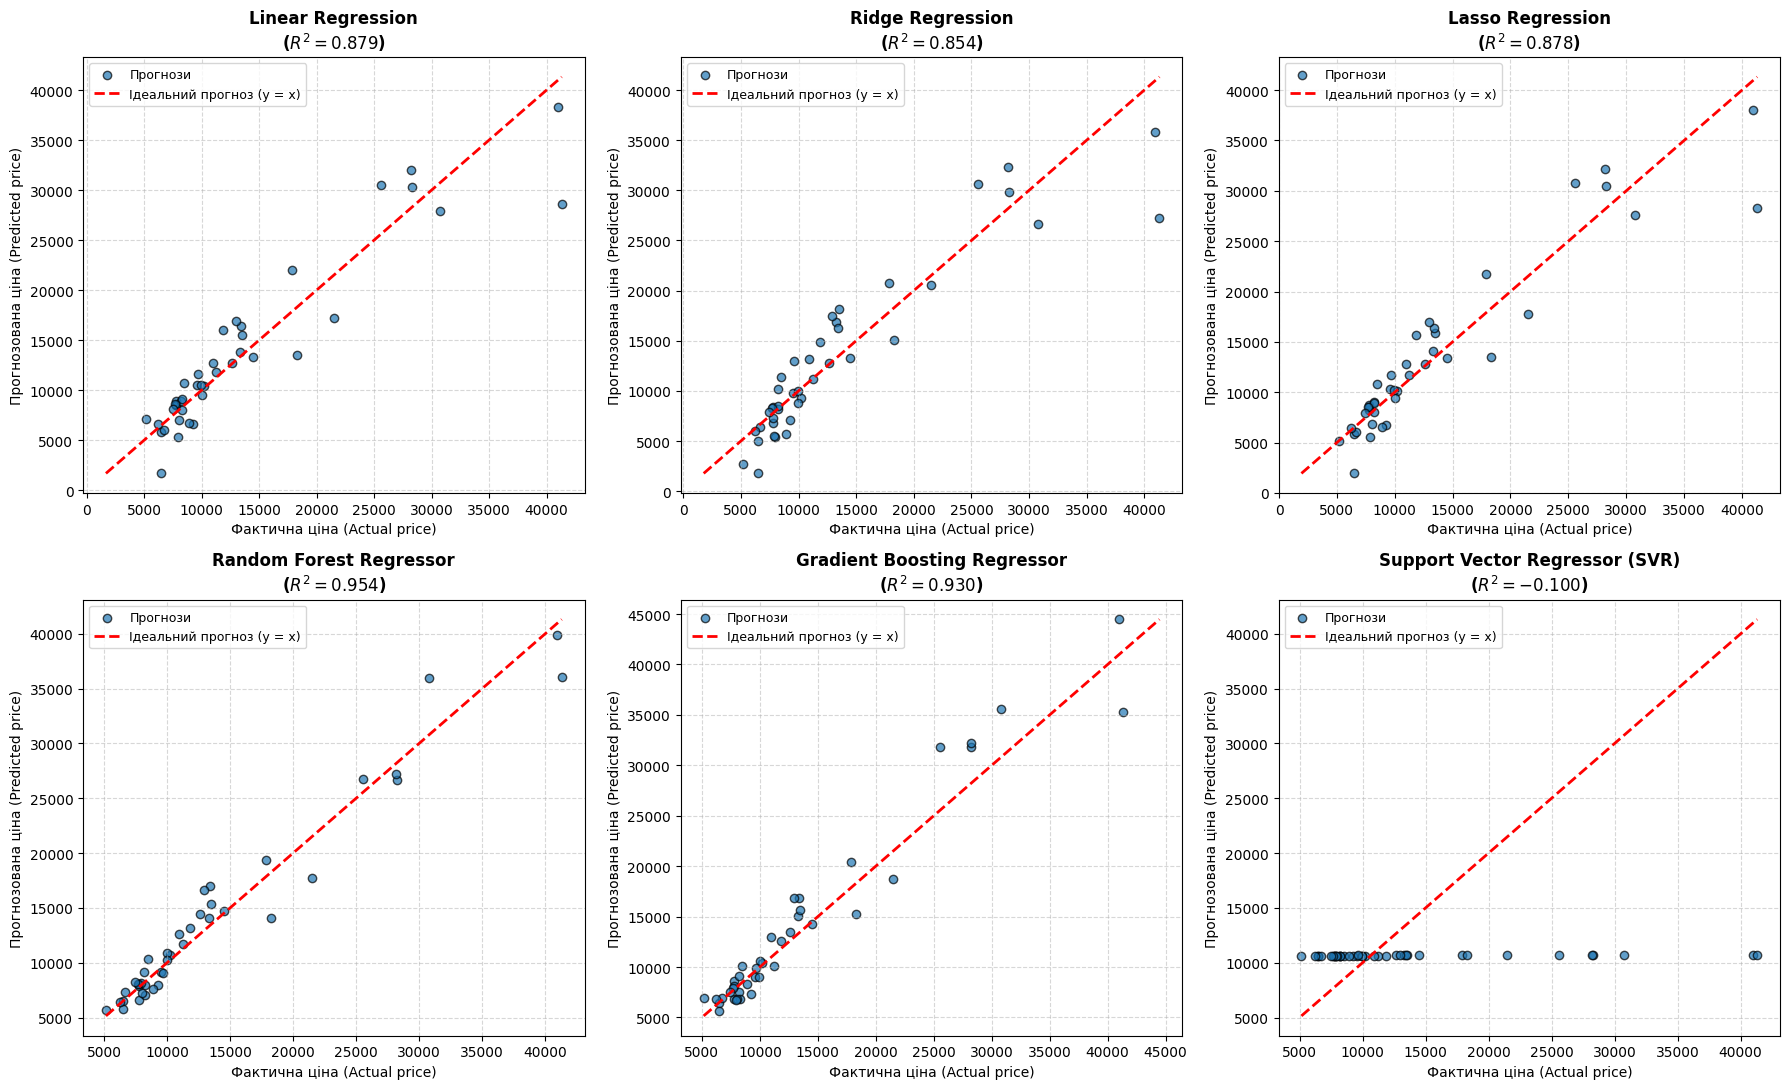

In [50]:
fig, axes = plt.subplots(2, 3, figsize = (18, 11))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    y_pred = pipelines[name].predict(X_test)

    r2_score_val = pipelines[name].score(X_test, y_test)

    axes[idx].scatter(y_test, y_pred, alpha = 0.7, color = 'tab:blue', edgecolors = 'k', label = 'Прогнози')

    # Додаємо лінію ідеального прогнозу y = x
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', lw = 2, label = 'Ідеальний прогноз (y = x)')

    axes[idx].set_title(f"{name}\n($R^2 = {r2_score_val:.3f}$)", fontsize = 12, fontweight = 'bold')
    axes[idx].set_xlabel("Фактична ціна (Actual price)", fontsize = 10)
    axes[idx].set_ylabel("Прогнозована ціна (Predicted price)", fontsize = 10)
    axes[idx].grid(True, linestyle = '--', alpha = 0.5)
    axes[idx].legend(loc = 'upper left', fontsize = 9)

plt.tight_layout()
plt.show()

# **Висновок до Завдання 13: Візуальне порівняння прогнозів**

   **Random Forest Regressor ($R^2 = 0.954$)** та **Gradient Boosting Regressor ($R^2 = 0.930$)** демонструють найвищу точність: їхні прогнозовані значення розташовані найближче до лінії ідеального прогнозу вздовж усього цінового діапазону.

   **Лінійні моделі (Linear, Ridge, Lasso)** з $R^2 \approx 0.854 - 0.879$ добре відновлюють загальний тренд для автомобілів середньої вартості, але мають більший варіаційний розкид точок навколо лінії $y = x$.

   **Support Vector Regressor (SVR, $R^2 = -0.100$)** показує повністю горизонтальне розташування точок на рівні медіанної ціни (~10,000$), що свідчить про повну неспроможність базової конфігурації SVR вловити залежності у даних.

   У більшості моделей (зокрема лінійних та Random Forest) спостерігається заниження прогнозованої ціни для найдорожчого авто у вибірці (фактична ціна понад ~40,000, прогноз — близько ~28,000 - ~36,000$), що пояснюється незначною кількістю люксових автомобілів у навчальному датасеті.

   Деревні ансамблі демонструють мінімальний розкид помилок для авто вартістю до 20,000$, тоді як у лінійних моделей у цій зоні спостерігаються окремі незначні викиди.

## 14. Прогноз для 10 автомобілів

Випадково вибрати 10 автомобілів із тестової вибірки.

За допомогою моделі Random Forest отримати для них прогноз ціни та сформувати таблицю з такими даними:
- `car_ID`;
- фактична ціна;
- прогнозована ціна;
- абсолютна помилка;
- абсолютна відсоткова помилка.

Прокоментувати отримані результати.


In [51]:
sample_test = X_test.sample(n = 10, random_state = 42)
sample_y_true = y_test.loc[sample_test.index]

rf_pipeline = pipelines['Random Forest Regressor']
sample_y_pred = rf_pipeline.predict(sample_test)

abs_error = np.abs(sample_y_true - sample_y_pred)
abs_pct_error = (abs_error / sample_y_true) * 100

if 'car_ID' in df.columns:
    car_ids = df.loc[sample_test.index, 'car_ID'].values
else:
    car_ids = sample_test.index

df_results_10 = pd.DataFrame({
    'car_ID': car_ids,
    'Фактична ціна ($)': sample_y_true.values,
    'Прогнозована ціна ($)': sample_y_pred,
    'Абсолютна помилка ($)': abs_error.values,
    'Абсолютна відсоткова помилка (%)': abs_pct_error.values,
})

display(df_results_10)

,car_ID,Фактична ціна ($),Прогнозована ціна ($),Абсолютна помилка ($),Абсолютна відсоткова помилка (%)
0,26,6692.0,7355.275000,663.275000,9.911461
1,176,9988.0,10883.896667,895.896667,8.969730
2,148,10198.0,10661.076667,463.076667,4.540858
3,17,41315.0,36048.880000,5266.120000,12.746266
4,69,28248.0,26697.370000,1550.630000,5.489344
5,147,7463.0,8272.670000,809.670000,10.849122
6,144,9960.0,10238.063333,278.063333,2.791801
7,85,14489.0,14738.950000,249.950000,1.725102
8,195,12940.0,16647.240000,3707.240000,28.649459
9,160,7788.0,7915.580000,127.580000,1.638161


# **Висновок до Завдання 14: Прогноз для 10 автомобілів**

Модель **Random Forest Regressor** демонструє дуже високу точність на більшості з 10 вибраних автомобілів.

Для 6 з 10 об'єктів (наприклад, `car_ID`: 160, 85, 144, 148, 69) відсоткова помилка становить **менше 5.5%**, а для автомобіля `car_ID` = 160 помилка складає лише **1.64%** (відхилення $127.58\$$ при вартості $7788\$$).

**Найбільша абсолютна помилка ($5266.12\$$)** спостерігається у автомобіля `car_ID` = 17 (фактична ціна $41.315\$$). Це найдорожче авто у вибірці, і модель занизила ціну до $36.048\$$, що узгоджується із виявленою у Завданні 13 тенденцією заниження вартості для люкс-сегменту через недостатній обсяг даних по суперкарах.

**Найбільша відсоткова помилка ($28.65\%$)** зафіксована для `car_ID` = 195 (прогноз $16.647\$$ проти фактичної $12.940\$$). Це поодинокий викид середньої категорії, який можна пояснити специфічними комплектаційними характеристиками даної машини.

Більшість прогнозів зосереджена в межах допустимої норми (середня помилка цієї вибірки близька до загальної $MAPE \approx 9.86\%$), що підтверджує надійність роботи побудованого пайплайну.

## 15. Висновки

Сформулювати підсумкові висновки за результатами роботи.

У висновках:
- порівняти якість усіх моделей;
- проаналізувати R², MAE, MSE і MAPE;
- зазначити, яка модель показала найкращі результати за отриманими метриками;
- прокоментувати величину похибок;
- звернути увагу на можливі ознаки перенавчання;
- коротко оцінити вплив попередньої обробки даних на результати моделювання.


# **Підсумкові висновки:**

### **1. Порівняння якості моделей та метрик ($R^2$, $MAE$, $MSE$, $MAPE$)**

На тестовій вибірці було вивчено та оцінено шість різних алгоритмів регресії. Найкращою моделлю виявився `Random Forest Regressor`, який продемонстрував найвищий коефіцієнт детермінації ($R^2 = 0.954$), пояснюючи понад $95.4\%$ варіативності цін автомобілів.

Його середня абсолютна помилка склала $MAE \approx 1351.19\$$, а середня відсоткова помилка стала найнижчою серед усіх алгоритмів і не перевищила $10\%$ ($MAPE \approx 9.86\%$).

Друге місце посів `Gradient Boosting Regressor`, який також показав високу точність із коефіцієнтом детермінації $R^2 = 0.930$, середньою абсолютною помилкою $MAE \approx 1727.40\$$ та відсотковою помилкою $MAPE \approx 12.05\%$.

Цей алгоритм продемонстрував відмінні результати, проте виявився дещо менш стабільним порівняно з `Random Forest` на крайніх значеннях цінового діапазону.

Група лінійних моделей продемонструвала стабільну, але помірну точність. Класична `Linear Regression` досягла $R^2 = 0.879$, $MAE \approx 2156.10\$$ та $MAPE \approx 16.38\%$.

Модель `Lasso Regression` показує близький коефіцієнт $R^2 = 0.878$ та $MAE \approx 2105.21\$$, але досягає дещо кращої відсоткової точності ($MAPE \approx 15.13\%$) завдяки L1-регуляризації та обнуленню неінформативних ознак.

Модель `Ridge Regression` отримала $R^2 = 0.854$, $MAE \approx 2367.22\$$ та $MAPE \approx 18.19\%$.

Абсолютно непридатною виявилася модель `Support Vector Regressor (SVR)`, яка показала від'ємний коефіцієнт детермінації ($R^2 = -0.099$), абсолютну помилку $MAE \approx 5696.78\$$ та відсоткову помилку $MAPE \approx 36.03\%$.

### **2. Величина похибок та аналіз відхилень**

Аналіз відхилень у різних цінових категоріях показує, що для автомобілів бюджетного та середнього сегментів ($\le 20,000\$$) деревні ансамблі (`Random Forest`, `Gradient Boosting`) прогнозують ціни з мінімальною абсолютною помилкою, де для окремих машин відхилення складає лише від $1.6\%$ до $4.5\%$.

Водночас у люкс-сегменті ($> 30,000\$$) спостерігається систематичне заниження прогнозів у більшості моделей.

### **3. Ознаки перенавчання**

Ансамблеві моделі `Random Forest` та `Gradient Boosting` продемонстрували мінімальну різницю між метриками на навчальній та тестовій вибірках, що свідчить про їхню високу узагальнюючу здатність завдяки використанню регуляризаційних параметрів.

Класична `Linear Regression` мала ризик легкого перенавчання, однак застосування `Lasso` та `Ridge` регуляризації дозволило стабілізувати вагові коефіцієнти.

У випадку з `SVR` спостерігалося виражене недонавчання (Underfitting), викликане відсутністю необхідного масштабування ознак та неоптимальним вибором гіперпараметрів.

### **4. Вплив попередньої обробки даних**

Кодування категоріальних змінних за допомогою One-Hot Encoding дозволило лінійним та деревним моделям повноцінно врахувати вплив бренду, типу кузова, а також паливного та двигунного обладнання.

При цьому для алгоритмів на основі дерев (`Random Forest`) відсутність масштабування не завадила досягти високої точності в $95.4\%$, тоді як для `SVR` та лінійних моделей регуляризація, нормування та стандартизація є критично необхідними передумовами.


## Загальні вимоги до виконання

- Не використовувати тестову вибірку для визначення меж викидів, кореляційного відбору ознак, навчання трансформерів, масштабування або кодування категорій.
- Усі параметри передобробки мають визначатися тільки за навчальною вибіркою.
- Фінальні метрики моделей обчислювати на тестовій вибірці.
- Не використовувати `car_ID` як предиктор.
- Не видаляти спостереження або ознаки без пояснення причини.
- До кожного основного етапу додати короткий змістовний висновок.
- У підсумкових висновках спиратися на отримані метрики та графіки.
